# DEC Segment Features

Learns the deep embedded clustering (DEC) features that form XMV-Net's `dec_segment` view: a cluster identity, soft cluster probabilities and a latent embedding for every account.

Clustering is unsupervised: `CHURN` is never an input. Labels appear only when reporting cluster composition. Sections 1–5 are the exploratory checks that preceded the pipeline.

## 1 · Session setup

Imports, display options and the random seed. The `%pip install` line is needed only if the runtime lacks a package.

In [3]:
# Uncomment only if your Kaggle runtime is missing packages.
# %pip install -q "dask[dataframe]" pyarrow fastparquet lightgbm

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="Set2")

RANDOM_STATE = 42
OBS_START = pd.Timestamp("2024-01-01")
OBS_END = pd.Timestamp("2024-03-31")
PRED_START = pd.Timestamp("2024-04-01")
PRED_END = pd.Timestamp("2024-04-30")

## 2 · Locate the data

Resolves the competition data root across Kaggle and local directory layouts.

In [4]:
def find_data_root() -> Path:
    candidates = [
        Path("/kaggle/input/competitions/bkash-presents-nsucec-datathon/public"),
        Path("/kaggle/input/bkash-presents-nsucec-datathon/public"),
        Path("/kaggle/input/bkash-presents-nsucec-datathon"),
        Path("../input/bkash-presents-nsucec-datathon/public"),
        Path("../input/bkash-presents-nsucec-datathon"),
        Path("bkash-presents-nsucec-datathon/public"),
        Path("./public"),
    ]

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates += list(kaggle_input.glob("*/public"))
        candidates += list(kaggle_input.glob("*"))

    for root in candidates:
        if (root / "train_labels.csv").exists() and (root / "kyc.parquet").exists():
            return root

    raise FileNotFoundError("Could not find dataset root. Check Kaggle Add Input or local path.")

DATA_ROOT = find_data_root()
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
TRX_PATH = DATA_ROOT / "transactions" / "*.parquet"
BAL_PATH = DATA_ROOT / "dayend_balance" / "*.parquet"

print("DATA_ROOT:", DATA_ROOT)
print("WORK_DIR:", WORK_DIR)
print("Transaction files:", sorted(p.name for p in (DATA_ROOT / "transactions").glob("*.parquet")))
print("Balance files:", sorted(p.name for p in (DATA_ROOT / "dayend_balance").glob("*.parquet")))

DATA_ROOT: /kaggle/input/competitions/bkash-presents-nsucec-datathon/public
WORK_DIR: /kaggle/working
Transaction files: ['trx_2024-01.parquet', 'trx_2024-02.parquet', 'trx_2024-03.parquet']
Balance files: ['balance_2024-01.parquet', 'balance_2024-02.parquet', 'balance_2024-03.parquet']


## 3 · File inventory and labels

Lists the source tables with their sizes, then confirms the label distribution.

In [5]:
inventory = []
for path in sorted(DATA_ROOT.rglob("*")):
    if path.is_file():
        inventory.append({
            "relative_path": str(path.relative_to(DATA_ROOT)),
            "size_mb": path.stat().st_size / 1024**2,
        })

inventory_df = pd.DataFrame(inventory).sort_values("size_mb", ascending=False)
display(inventory_df)

train_labels = pd.read_csv(DATA_ROOT / "train_labels.csv")
test_ids = pd.read_csv(DATA_ROOT / "test.csv")
sample_submission = pd.read_csv(DATA_ROOT / "sample_submission.csv")

print("train_labels:", train_labels.shape)
print("test_ids:", test_ids.shape)
print("sample_submission:", sample_submission.shape)
display(train_labels.head())
display(test_ids.head())
display(sample_submission.head())

,relative_path,size_mb
8,transactions/trx_2024-01.parquet,529.253078
10,transactions/trx_2024-03.parquet,511.039122
9,transactions/trx_2024-02.parquet,488.375721
1,dayend_balance/balance_2024-01.parquet,126.970257
2,dayend_balance/balance_2024-02.parquet,99.140504
3,dayend_balance/balance_2024-03.parquet,95.039609
7,train_labels.csv,8.511559
4,kyc.parquet,6.749902
5,sample_submission.csv,4.134199
6,test.csv,3.161441


train_labels: (595000, 2)
test_ids: (255000, 1)
sample_submission: (255000, 2)


,ACCOUNT_ID,CHURN
0,CUST00109362,0
1,CUST00480386,0
2,CUST00637759,0
3,CUST00303030,0
4,CUST00395836,0


,ACCOUNT_ID
0,CUST00074385
1,CUST00290073
2,CUST00247934
3,CUST00314276
4,CUST00522755


,ACCOUNT_ID,CHURN_PROB
0,CUST00074385,0.5
1,CUST00290073,0.5
2,CUST00247934,0.5
3,CUST00314276,0.5
4,CUST00522755,0.5


Churn base rate in `train_labels.csv`.

,CHURN,count,rate
0,0,519565,0.873218
1,1,75435,0.126782


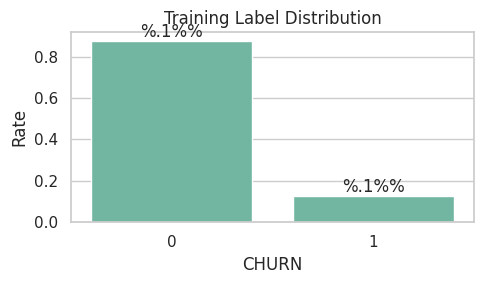

In [6]:
label_counts = train_labels["CHURN"].value_counts().rename_axis("CHURN").reset_index(name="count")
label_counts["rate"] = label_counts["count"] / len(train_labels)
display(label_counts)

plt.figure(figsize=(5, 3))
ax = sns.barplot(data=label_counts, x="CHURN", y="rate")
ax.bar_label(ax.containers[0], fmt="%.1%%")
plt.title("Training Label Distribution")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

## 4 · Table inspection

Schema and row counts for the transaction, balance and KYC tables, read lazily with Dask so nothing is loaded into memory.

In [9]:
kyc_dd = dd.read_parquet(str(DATA_ROOT / "kyc.parquet"), engine="pyarrow")
trx_dd = dd.read_parquet(str(TRX_PATH), engine="pyarrow")
bal_dd = dd.read_parquet(str(BAL_PATH), engine="pyarrow")

tables = {"kyc": kyc_dd, "transactions": trx_dd, "dayend_balance": bal_dd}
schema_rows = []
for table_name, ddf in tables.items():
    for col, dtype in ddf.dtypes.items():
        schema_rows.append({
            "table": table_name,
            "column": col,
            "dtype": str(dtype),
            "npartitions": ddf.npartitions,
        })

schema_df = pd.DataFrame(schema_rows)
display(schema_df)

row_counts = {name: int(ddf.map_partitions(len).compute().sum()) for name, ddf in tables.items()}
row_counts

,table,column,dtype,npartitions
0,kyc,ACCOUNT_ID,string,1
1,kyc,ACCOUNT_TYPE,string,1
2,kyc,ACCOUNT_OPEN_DATE,datetime64[ns],1
3,kyc,GENDER,string,1
4,kyc,REGION,string,1
5,transactions,TrxID,string,18
6,transactions,TRX_DATETIME,string,18
7,transactions,SRC_ACCOUNT,string,18
8,transactions,DST_ACCOUNT,string,18
9,transactions,TRX_TYPE,string,18


{'kyc': 1000000, 'transactions': 73281378, 'dayend_balance': 77350000}

Per-table schema and row counts.

In [40]:
for name, ddf in tables.items():
    print("\n" + "=" * 80)
    print(name, "npartitions=", ddf.npartitions)
    display(ddf.head(5))


kyc npartitions= 1


,ACCOUNT_ID,ACCOUNT_TYPE,ACCOUNT_OPEN_DATE,GENDER,REGION
0,CUST00000001,Customer,2020-03-21,Male,Sylhet
1,CUST00000002,Customer,2020-06-02,Male,Barishal
2,CUST00000003,Customer,2020-12-13,Female,Dhaka
3,CUST00000004,Customer,2020-06-29,Male,Chattogram
4,CUST00000005,Customer,2021-02-02,Male,Chattogram



transactions npartitions= 18


,TrxID,TRX_DATETIME,SRC_ACCOUNT,DST_ACCOUNT,TRX_TYPE,TRX_AMT
0,TRX000000000000001,2024-01-02 12:05:01,CUST00000001,BILL00035997,BillPay,41.98
1,TRX000000000000002,2024-01-02 16:31:26,CUST00000001,BILL00047247,BillPay,93391.24
2,TRX000000000000003,2024-01-03 16:18:44,CUST00000001,CUST00000001,CashIn,158.69
3,TRX000000000000004,2024-01-07 16:03:42,CUST00000001,CUST00000001,CashIn,184.12
4,TRX000000000000005,2024-01-08 16:09:24,CUST00000001,CUST00000001,CashIn,20704.57



dayend_balance npartitions= 3


,ACCOUNT_ID,DATE,AVAILABLE_BALANCE
0,CUST00000001,2024-01-01,2719.98
1,CUST00000001,2024-01-02,0.00
2,CUST00000001,2024-01-03,157.25
3,CUST00000001,2024-01-04,153.84
4,CUST00000001,2024-01-05,152.86


## 5 · KYC exploration

Distribution checks on the account table: tenure, gender and region.

In [41]:
kyc = pd.read_parquet(DATA_ROOT / "kyc.parquet")
kyc["ACCOUNT_OPEN_DATE"] = pd.to_datetime(kyc["ACCOUNT_OPEN_DATE"])
kyc["account_age_days"] = (OBS_END - kyc["ACCOUNT_OPEN_DATE"]).dt.days.clip(lower=0)

target_ids = pd.concat([train_labels[["ACCOUNT_ID"]], test_ids[["ACCOUNT_ID"]]], ignore_index=True).drop_duplicates()
target_kyc = target_ids.merge(kyc, on="ACCOUNT_ID", how="left")

print("All KYC:", kyc.shape)
print("Target KYC:", target_kyc.shape)
display(target_kyc.head())
display(target_kyc.isna().mean().sort_values(ascending=False).to_frame("missing_rate"))

All KYC: (1000000, 6)
Target KYC: (850000, 6)


,ACCOUNT_ID,ACCOUNT_TYPE,ACCOUNT_OPEN_DATE,GENDER,REGION,account_age_days
0,CUST00109362,Customer,2020-04-25,Male,Dhaka,1436
1,CUST00480386,Customer,2021-06-05,Female,Chattogram,1030
2,CUST00637759,Customer,2019-12-27,Female,Chattogram,1556
3,CUST00303030,Customer,2020-11-09,Male,Sylhet,1238
4,CUST00395836,Customer,2021-01-20,Male,Khulna,1166


,missing_rate
ACCOUNT_ID,0.0
ACCOUNT_TYPE,0.0
ACCOUNT_OPEN_DATE,0.0
GENDER,0.0
REGION,0.0
account_age_days,0.0


Distribution plots for the three KYC fields.

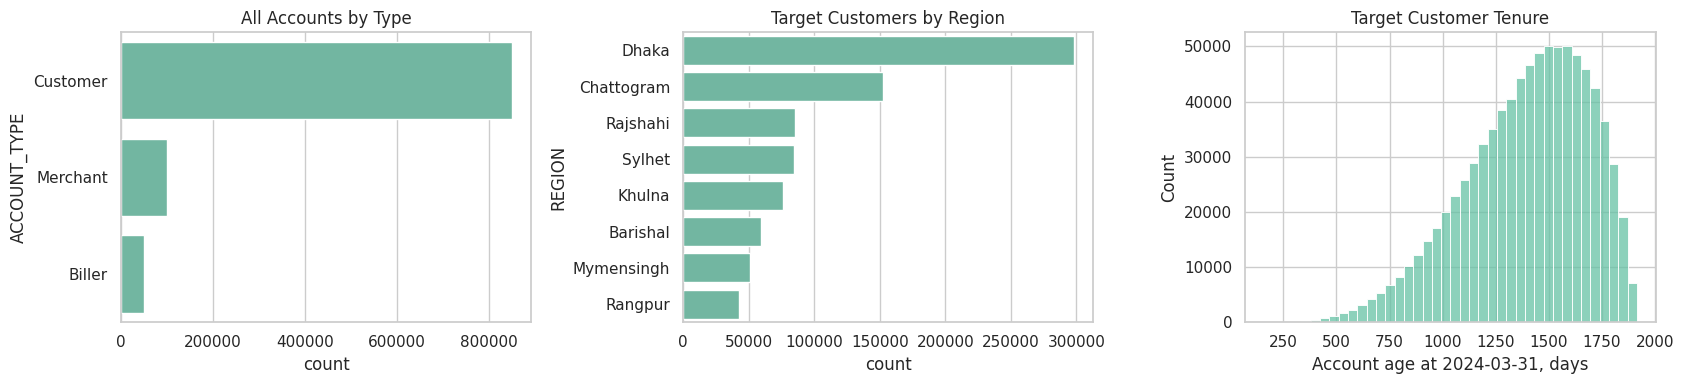

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.countplot(data=kyc, y="ACCOUNT_TYPE", order=kyc["ACCOUNT_TYPE"].value_counts().index, ax=axes[0])
axes[0].set_title("All Accounts by Type")
sns.countplot(data=target_kyc, y="REGION", order=target_kyc["REGION"].value_counts().index, ax=axes[1])
axes[1].set_title("Target Customers by Region")
sns.histplot(target_kyc["account_age_days"], bins=40, ax=axes[2])
axes[2].set_title("Target Customer Tenure")
axes[2].set_xlabel("Account age at 2024-03-31, days")
plt.tight_layout()
plt.show()

## 6 · DEC pipeline

Everything below produces the `dec_segment` view. Steps 6.1–6.8 follow the DEC method: select inputs, preprocess, pretrain an autoencoder, choose the cluster count, train DEC, then export.

The next cell holds the imports and reproducibility settings for this stage.

In [8]:
# Paper pipeline imports and reproducibility setup

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

2026-06-15 08:14:46.542223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781511286.713154      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781511286.762477      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781511287.168802      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511287.168833      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781511287.168836      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


### 6.1 · Select DEC inputs

Loads the 191 numeric features exported by the dataset notebook. `CHURN` is excluded from the input matrix.

In [9]:
DEC_OUTPUT_DIR = WORK_DIR / "dec_outputs"
DEC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEC_FEATURE_PATH = Path(
    "/kaggle/input/datasets/jwuptr/all-numeric-features/march_split_native_numeric_features_for_dec.parquet"
)

feature_source = pd.read_parquet(DEC_FEATURE_PATH)
print("Loaded DEC numeric feature input from:", DEC_FEATURE_PATH)

if "ACCOUNT_ID" not in feature_source.columns:
    raise ValueError("DEC feature source must contain ACCOUNT_ID.")

feature_source["ACCOUNT_ID"] = feature_source["ACCOUNT_ID"].astype(str)
train_labels["ACCOUNT_ID"] = train_labels["ACCOUNT_ID"].astype(str)
test_ids["ACCOUNT_ID"] = test_ids["ACCOUNT_ID"].astype(str)

# Drop duplicate accounts, if any
feature_source = feature_source.drop_duplicates(subset=["ACCOUNT_ID"]).copy()

# Use every column except ACCOUNT_ID as DEC input
DEC_FEATURES = [c for c in feature_source.columns if c != "ACCOUNT_ID"]

# Safety: keep only numeric/bool columns
numeric_dec_features = feature_source[DEC_FEATURES].select_dtypes(
    include=["number", "bool"]
).columns.tolist()

dropped_non_numeric = [c for c in DEC_FEATURES if c not in numeric_dec_features]

if dropped_non_numeric:
    print("Dropped non-numeric columns:", dropped_non_numeric)

DEC_FEATURES = numeric_dec_features

dec_feature_source = feature_source[["ACCOUNT_ID"] + DEC_FEATURES].copy()

train_model_df = train_labels.merge(
    dec_feature_source,
    on="ACCOUNT_ID",
    how="left"
)

test_model_df = test_ids.merge(
    dec_feature_source,
    on="ACCOUNT_ID",
    how="left"
)

X_raw = train_model_df[DEC_FEATURES].copy()
y = train_model_df["CHURN"].astype(int).copy()
X_test_raw = test_model_df[DEC_FEATURES].copy()

cat_cols = []
num_cols = DEC_FEATURES.copy()
model_feature_cols = DEC_FEATURES.copy()

print("DEC train shape:", X_raw.shape)
print("DEC test shape:", X_test_raw.shape)
print("Selected DEC feature count:", len(model_feature_cols))
print("Numeric DEC features:", len(num_cols))
print("Categorical DEC features:", cat_cols)
print("Churn rate:", y.mean())

dec_selected_features = pd.DataFrame({"feature": DEC_FEATURES})
dec_selected_features.to_csv(
    DEC_OUTPUT_DIR / "dec_selected_all_numeric_features.csv",
    index=False
)

display(dec_selected_features)

Loaded DEC numeric feature input from: /kaggle/input/datasets/jwuptr/all-numeric-features/march_split_native_numeric_features_for_dec.parquet
DEC train shape: (595000, 191)
DEC test shape: (255000, 191)
Selected DEC feature count: 191
Numeric DEC features: 191
Categorical DEC features: []
Churn rate: 0.12678151260504203


,feature
0,tenure_days
1,tenure_0_90d
2,tenure_91_180d
3,tenure_181_365d
4,tenure_1_2y
...,...
186,region_balance_zscore
187,region_recency_deviation
188,region_churn_rate
189,region_high_risk_flag


### 6.2 · Preprocessing

Semantic fills for missing values, clipping to train-only bounds, and z-score normalisation fitted on training rows. DEC is distance-based, so feature scale determines the clustering.

In [10]:
# DEC preprocessing for the selected SHAP top-40 features

# 1) Missing/null audit before cleaning
missing_report_before = pd.DataFrame({
    'missing_count': X_raw.isna().sum(),
    'missing_rate': X_raw.isna().mean(),
    'dtype': X_raw.dtypes.astype(str),
}).sort_values('missing_rate', ascending=False)

display(missing_report_before.head(40))
missing_report_before.to_csv(DEC_OUTPUT_DIR / 'dec_missing_report_before_preprocessing.csv')

# 2) DEC uses numeric engineered behavior features. Coerce any accidental object columns safely.
X_raw_clean = X_raw.copy()
X_test_raw_clean = X_test_raw.copy()

for col in DEC_FEATURES:
    X_raw_clean[col] = pd.to_numeric(X_raw_clean[col], errors='coerce')
    X_test_raw_clean[col] = pd.to_numeric(X_test_raw_clean[col], errors='coerce')

X_raw_clean = X_raw_clean.replace([np.inf, -np.inf], np.nan)
X_test_raw_clean = X_test_raw_clean.replace([np.inf, -np.inf], np.nan)

# 3) Semantic fills. These are fitted from domain meaning, not from the target.
# Remaining missing values are handled by a train-median imputer below.
semantic_fill_values = {
    'recency_days': 91,
    'mean_gap_days': 91,
    'activity_drop_ratio': 1,
    'late_march_share': 0,
    'late_march_active_share': 0,
    'rec_8_29': 0,
    'region_recency_deviation': 0,
}

zero_fill_prefixes = (
    'n_trx_',
    'out_trx_cnt_',
    'active_days_',
    'zero_days_',
    'cnt_m',
    'n_limit_',
    'n_sunday_',
    'n_salary_',
)
zero_fill_contains = (
    'ratio',
    'share',
    'momentum',
)
std_fill_contains = (
    'std',
)

applied_semantic_fills = {}
for col in DEC_FEATURES:
    fill_value = None
    if col in semantic_fill_values:
        fill_value = semantic_fill_values[col]
    elif col.startswith(zero_fill_prefixes):
        fill_value = 0
    elif any(token in col for token in zero_fill_contains):
        fill_value = 0
    elif any(token in col for token in std_fill_contains):
        fill_value = 0

    if fill_value is not None:
        X_raw_clean[col] = X_raw_clean[col].fillna(fill_value)
        X_test_raw_clean[col] = X_test_raw_clean[col].fillna(fill_value)
        applied_semantic_fills[col] = fill_value

pd.DataFrame({
    'feature': list(applied_semantic_fills.keys()),
    'semantic_fill_value': list(applied_semantic_fills.values()),
}).to_csv(DEC_OUTPUT_DIR / 'dec_semantic_fill_values.csv', index=False)

# 4) Clip extreme values using training data only. This keeps outliers from dominating DEC distance geometry.
bounded_01_cols = [
    'late_march_share',
    'late_march_active_share',
    'freq_recent_share_7d',
    'freq_recent_share_30d',
    'salary_day_ratio_14d',
    'salary_day_ratio_7d',
    'salary_amt_ratio_7d',
]

non_negative_prefixes = (
    'n_trx_',
    'out_trx_cnt_',
    'active_days_',
    'zero_days_',
    'cnt_m',
    'n_limit_',
    'n_sunday_',
    'n_salary_',
    'std_bal_',
    'balance_std_',
    'mean_bal_',
)

clip_rows = []
for col in DEC_FEATURES:
    train_col = X_raw_clean[col]

    if col in bounded_01_cols:
        lo, hi = 0.0, 1.0
    elif col.startswith(non_negative_prefixes):
        lo = 0.0
        hi = train_col.quantile(0.995)
    else:
        lo, hi = train_col.quantile([0.01, 0.99])

    if pd.isna(lo):
        lo = 0.0
    if pd.isna(hi):
        hi = lo
    if hi < lo:
        lo, hi = hi, lo

    X_raw_clean[col] = X_raw_clean[col].clip(lo, hi)
    X_test_raw_clean[col] = X_test_raw_clean[col].clip(lo, hi)
    clip_rows.append({'feature': col, 'clip_lower': float(lo), 'clip_upper': float(hi)})

clip_bounds = pd.DataFrame(clip_rows)
clip_bounds.to_csv(DEC_OUTPUT_DIR / 'dec_clip_bounds_train_only.csv', index=False)
display(clip_bounds.head(40))

# 5) Final missingness audit after semantic fills/clipping, before median imputation.
missing_report_after = pd.DataFrame({
    'missing_count': X_raw_clean.isna().sum(),
    'missing_rate': X_raw_clean.isna().mean(),
    'dtype': X_raw_clean.dtypes.astype(str),
}).sort_values('missing_rate', ascending=False)

display(missing_report_after.head(40))
missing_report_after.to_csv(DEC_OUTPUT_DIR / 'dec_missing_report_after_semantic_cleaning.csv')

# Save cleaned-but-unscaled inputs for inspection or reuse.
train_dec_clean_unscaled = pd.concat(
    [train_model_df[['ACCOUNT_ID']].reset_index(drop=True), y.reset_index(drop=True).rename('CHURN'), X_raw_clean.reset_index(drop=True)],
    axis=1,
)
test_dec_clean_unscaled = pd.concat(
    [test_model_df[['ACCOUNT_ID']].reset_index(drop=True), X_test_raw_clean.reset_index(drop=True)],
    axis=1,
)
train_dec_clean_unscaled.to_parquet(DEC_OUTPUT_DIR / 'dec_top40_clean_unscaled_train.parquet', index=False)
test_dec_clean_unscaled.to_parquet(DEC_OUTPUT_DIR / 'dec_top40_clean_unscaled_test.parquet', index=False)

# 6) Median imputation for any remaining gaps, then z-score normalization.
num_cols = DEC_FEATURES.copy()
cat_cols = []

preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('zscore', StandardScaler()),
])

# Fit preprocessing on training rows only to avoid leakage.
X_all = preprocess.fit_transform(X_raw_clean)
X_test_all = preprocess.transform(X_test_raw_clean)
processed_feature_names = DEC_FEATURES.copy()

X_all = X_all.astype('float32')
X_test_all = X_test_all.astype('float32')

# Save scaled matrices as parquet for transparent reuse/debugging.
train_scaled_df = pd.DataFrame(X_all, columns=processed_feature_names)
train_scaled_df.insert(0, 'ACCOUNT_ID', train_model_df['ACCOUNT_ID'].to_numpy())
train_scaled_df['CHURN'] = y.to_numpy()
test_scaled_df = pd.DataFrame(X_test_all, columns=processed_feature_names)
test_scaled_df.insert(0, 'ACCOUNT_ID', test_model_df['ACCOUNT_ID'].to_numpy())
train_scaled_df.to_parquet(DEC_OUTPUT_DIR / 'dec_top40_zscore_train.parquet', index=False)
test_scaled_df.to_parquet(DEC_OUTPUT_DIR / 'dec_top40_zscore_test.parquet', index=False)

print('Processed train matrix:', X_all.shape)
print('Processed test matrix:', X_test_all.shape)
print('Any train NaN:', np.isnan(X_all).any())
print('Any train inf:', np.isinf(X_all).any())
print('Saved preprocessing artifacts to:', DEC_OUTPUT_DIR)


,missing_count,missing_rate,dtype
uniq_merch_7d,371524,0.624410,float64
uniq_merch_14d,325669,0.547343,float64
uniq_merch_30d,279037,0.468970,float64
uniq_merch_60d,234379,0.393914,float64
uniq_merch_90d,207617,0.348936,float64
n_sunday_7d,112331,0.188792,float64
salary_amt_7d,112331,0.188792,float64
n_limit_7d,112331,0.188792,float64
uniq_cp_7d,112331,0.188792,float64
sunday_ratio_7d,112331,0.188792,float64


,feature,clip_lower,clip_upper
0,tenure_days,626.00000,1.868000e+03
1,tenure_0_90d,0.00000,0.000000e+00
2,tenure_91_180d,0.00000,0.000000e+00
3,tenure_181_365d,0.00000,0.000000e+00
4,tenure_1_2y,0.00000,1.000000e+00
5,tenure_2y_plus,0.00000,1.000000e+00
6,n_trx_7d,0.00000,3.100000e+01
7,total_amt_7d,36.88680,5.634262e+05
8,avg_amt_7d,34.27680,2.891109e+04
9,n_salary_7d,0.00000,0.000000e+00


,missing_count,missing_rate,dtype
uniq_merch_7d,371524,0.624410,float64
uniq_merch_14d,325669,0.547343,float64
uniq_merch_30d,279037,0.468970,float64
uniq_merch_60d,234379,0.393914,float64
uniq_merch_90d,207617,0.348936,float64
avg_amt_7d,112331,0.188792,float64
n_weekend_7d,112331,0.188792,float64
uniq_cp_7d,112331,0.188792,float64
total_amt_7d,112331,0.188792,float64
salary_amt_7d,112331,0.188792,float64


Processed train matrix: (595000, 191)
Processed test matrix: (255000, 191)
Any train NaN: False
Any train inf: False
Saved preprocessing artifacts to: /kaggle/working/dec_outputs


### 6.3 · Train/validation split

Stratified 80/20 split. The autoencoder and DEC are fitted on the training portion; the remainder is transformed only.

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y.to_numpy(),
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print('X_train:', X_train.shape, 'churn rate:', y_train.mean())
print('X_valid:', X_valid.shape, 'churn rate:', y_valid.mean())

X_train: (476000, 191) churn rate: 0.12678151260504203
X_valid: (119000, 191) churn rate: 0.12678151260504203


### 6.4 · Autoencoder pretraining

Compresses the 191 features to a 10-dimensional latent space (191 → 64 → 32 → 10). DEC clusters this latent representation rather than the raw features.

I0000 00:00:1781432266.802979      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781432266.809011      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ customer_features (InputLayer)  │ (None, 191)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_64 (Dense)            │ (None, 64)             │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_32 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_embedding (Dense)        │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_32 (Dense)            │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_64 (Dense)            │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 191)            │        12,415 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,577 (115.54 KB)

 Trainable params: 29,577 (115.54 KB)

...

Epoch 1/50


I0000 00:00:1781432271.424046     180 service.cc:152] XLA service 0x7f0d5400e020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781432271.424087     180 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781432271.424091     180 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781432271.856067     180 cuda_dnn.cc:529] Loaded cuDNN version 91002


 54/372 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8168

I0000 00:00:1781432273.434737     180 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


372/372 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.3602 - val_loss: 0.2145 - learning_rate: 0.0010
Epoch 2/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1929 - val_loss: 0.1783 - learning_rate: 0.0010
Epoch 3/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1701 - val_loss: 0.1640 - learning_rate: 0.0010
Epoch 4/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1592 - val_loss: 0.1552 - learning_rate: 0.0010
Epoch 5/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1517 - val_loss: 0.1491 - learning_rate: 0.0010
Epoch 6/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1464 - val_loss: 0.1448 - learning_rate: 0.0010
Epoch 7/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1425 - val_loss: 0.1413 - learning_rate: 0.0010
Epoch 8/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1394 - val_loss: 0.1385 - learning_rate: 0.0010
Epoch 9/50
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1367 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 10/50
372/372 

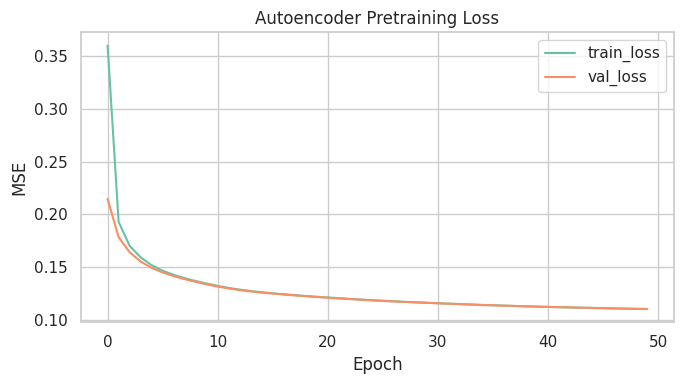

In [15]:
# Autoencoder pretraining for DEC latent representation

input_dim = X_train.shape[1]
latent_dim = 10

def build_autoencoder(input_dim, latent_dim=10):
    inp = keras.Input(shape=(input_dim,), name='customer_features')
    x = layers.Dense(64, activation='relu', name='enc_dense_64')(inp)
    x = layers.Dense(32, activation='relu', name='enc_dense_32')(x)
    z = layers.Dense(latent_dim, activation='linear', name='latent_embedding')(x)
    x = layers.Dense(32, activation='relu', name='dec_dense_32')(z)
    x = layers.Dense(64, activation='relu', name='dec_dense_64')(x)
    # Because we use z-score normalization, linear reconstruction is more appropriate than sigmoid.
    out = layers.Dense(input_dim, activation='linear', name='reconstruction')(x)
    autoencoder = keras.Model(inp, out, name='autoencoder')
    encoder = keras.Model(inp, z, name='encoder')
    autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder(input_dim, latent_dim)
autoencoder.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

AE_EPOCHS = 50
BATCH_SIZE = 1024  # Larger than paper batch size 32 for this much larger tabular dataset.

history_ae = autoencoder.fit(
    X_train, X_train,
    validation_split=0.20,
    epochs=AE_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

plt.figure(figsize=(7, 4))
plt.plot(history_ae.history['loss'], label='train_loss')
plt.plot(history_ae.history['val_loss'], label='val_loss')
plt.title('Autoencoder Pretraining Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

### 6.5 · Choose the cluster count

K-means inertia across K = 2–10 on the latent embeddings. The elbow indicates a suitable K.

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,K,inertia,inertia_drop,relative_drop_pct
0,2,117079792.0,NaN,NaN
1,3,70094928.0,46984864.0,40.130635
2,4,59202496.0,10892432.0,15.539544
3,5,51761796.0,7440700.0,12.568220
4,6,45604480.0,6157316.0,11.895484
5,7,41574032.0,4030448.0,8.837833
6,8,38186848.0,3387184.0,8.147355
7,9,35358108.0,2828740.0,7.407629
8,10,33854808.0,1503300.0,4.251642


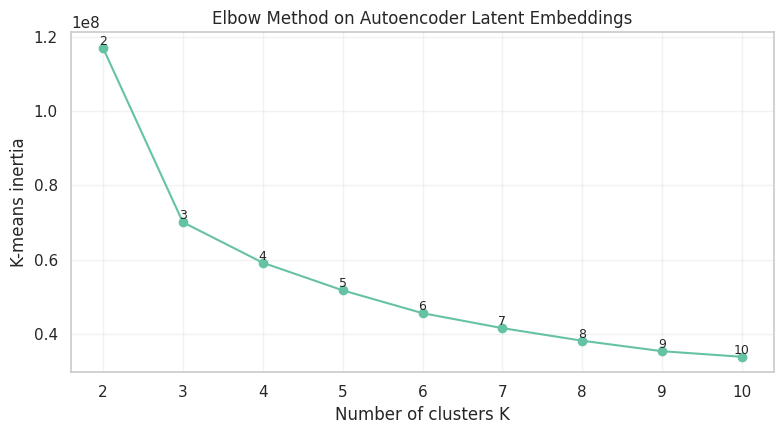

Automatic elbow/knee suggestion: 4
Paper selected K: 4
Decision rule: choose the visible elbow from the plot. Use 4 if the curve supports it or if you want strict paper alignment.


In [16]:
# Elbow method for choosing K, following the paper.
# Run this cell first, inspect the plot, then set N_CLUSTERS in the next cell.

Z_train = encoder.predict(X_train, batch_size=4096, verbose=1)
Z_valid = encoder.predict(X_valid, batch_size=4096, verbose=0)

k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(Z_train)
    inertias.append(km.inertia_)

elbow_df = pd.DataFrame({'K': k_values, 'inertia': inertias})
elbow_df['inertia_drop'] = elbow_df['inertia'].shift(1) - elbow_df['inertia']
elbow_df['relative_drop_pct'] = 100 * elbow_df['inertia_drop'] / elbow_df['inertia'].shift(1)
display(elbow_df)

plt.figure(figsize=(8, 4.5))
plt.plot(k_values, inertias, marker='o')
for k, inertia in zip(k_values, inertias):
    plt.text(k, inertia, str(k), fontsize=9, ha='center', va='bottom')
plt.title('Elbow Method on Autoencoder Latent Embeddings')
plt.xlabel('Number of clusters K')
plt.ylabel('K-means inertia')
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Simple knee heuristic: maximum distance to the line between first and last points.
points = np.column_stack([k_values, inertias]).astype(float)
line_start, line_end = points[0], points[-1]
line_vec = line_end - line_start
line_vec = line_vec / np.linalg.norm(line_vec)
distances = []
for p in points:
    proj_len = np.dot(p - line_start, line_vec)
    proj = line_start + proj_len * line_vec
    distances.append(np.linalg.norm(p - proj))

suggested_k = int(k_values[int(np.argmax(distances))])
PAPER_K = 4

print('Automatic elbow/knee suggestion:', suggested_k)
print('Paper selected K:', PAPER_K)
print('Decision rule: choose the visible elbow from the plot. Use 4 if the curve supports it or if you want strict paper alignment.')


Sets `N_CLUSTERS` after inspection of the curve above, kept in its own cell so the DEC steps can be re-run without repeating the search.

In [17]:
# Set this after inspecting the elbow curve.
# Recommended starting point: use suggested_k from the plot. Use 4 if the curve supports paper alignment.

MANUAL_K = 5  # Example: change to 3, 4, 5, etc. after reading the elbow plot.

if MANUAL_K is None:
    N_CLUSTERS = suggested_k
else:
    N_CLUSTERS = int(MANUAL_K)

print('DEC will use N_CLUSTERS =', N_CLUSTERS)


DEC will use N_CLUSTERS = 5


### 6.6 · Train DEC

K-means initialises the cluster centroids; DEC then minimises the KL divergence between its soft assignments and a sharpened target distribution.

iter=0, delta_label=0.000002
iter=140, delta_label=0.046819
iter=280, delta_label=0.051214
iter=420, delta_label=0.018933
iter=560, delta_label=0.009874
iter=700, delta_label=0.008668
iter=840, delta_label=0.005639
iter=980, delta_label=0.003649
iter=1120, delta_label=0.002233
iter=1260, delta_label=0.002569
iter=1400, delta_label=0.002324
iter=1540, delta_label=0.001874
iter=1680, delta_label=0.002221
iter=1820, delta_label=0.001561
iter=1960, delta_label=0.001893
iter=2100, delta_label=0.001828
iter=2240, delta_label=0.001429
iter=2380, delta_label=0.001622
iter=2520, delta_label=0.001179
iter=2660, delta_label=0.001080
iter=2800, delta_label=0.001809
iter=2940, delta_label=0.001126
iter=3080, delta_label=0.001387
iter=3220, delta_label=0.001111
iter=3360, delta_label=0.001105
iter=3500, delta_label=0.001174
iter=3640, delta_label=0.001437
iter=3780, delta_label=0.001263
iter=3920, delta_label=0.001011
iter=4060, delta_label=0.001149
iter=4200, delta_label=0.001124
iter=4340, delta_l

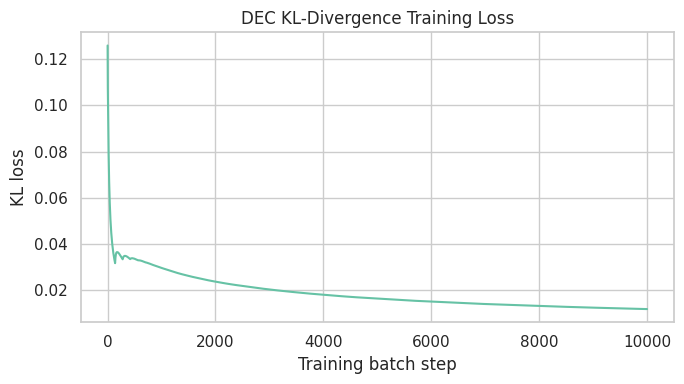

In [18]:
# DEC implementation: clustering layer + target distribution + KL-divergence training

class ClusteringLayer(layers.Layer):
    def __init__(self, n_clusters, alpha=1.0, **kwargs):
        super().__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha

    def build(self, input_shape):
        self.clusters = self.add_weight(
            shape=(self.n_clusters, int(input_shape[-1])),
            initializer='glorot_uniform',
            name='clusters'
        )
        super().build(input_shape)

    def call(self, inputs):
        q = 1.0 / (1.0 + (tf.reduce_sum(tf.square(tf.expand_dims(inputs, axis=1) - self.clusters), axis=2) / self.alpha))
        q = q ** ((self.alpha + 1.0) / 2.0)
        q = q / tf.reduce_sum(q, axis=1, keepdims=True)
        return q


def target_distribution(q):
    weight = (q ** 2) / np.sum(q, axis=0)
    return (weight.T / np.sum(weight, axis=1)).T

# Initialize DEC centroids with K-means on latent embeddings.
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
y_pred_init = kmeans.fit_predict(Z_train)

clustering_layer = ClusteringLayer(N_CLUSTERS, name='clustering')(encoder.output)
dec_model = keras.Model(inputs=encoder.input, outputs=clustering_layer, name='DEC')
dec_model.get_layer('clustering').set_weights([kmeans.cluster_centers_])
dec_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='kld')

DEC_MAX_ITER = 10000
DEC_UPDATE_INTERVAL = 140
DEC_BATCH_SIZE = 1024
DEC_TOL = 1e-4  # Paper reports very small convergence epsilon; this is practical for large Kaggle data.

index_array = np.arange(X_train.shape[0])
y_pred_last = y_pred_init.copy()
loss_values = []

for ite in range(DEC_MAX_ITER):
    if ite % DEC_UPDATE_INTERVAL == 0:
        q = dec_model.predict(X_train, batch_size=4096, verbose=0)
        p = target_distribution(q)
        y_pred = q.argmax(axis=1)
        delta_label = np.mean(y_pred != y_pred_last)
        y_pred_last = y_pred.copy()
        print(f'iter={ite}, delta_label={delta_label:.6f}')
        if ite > 0 and delta_label < DEC_TOL:
            print('DEC converged.')
            break

    batch_start = (ite * DEC_BATCH_SIZE) % X_train.shape[0]
    batch_end = min(batch_start + DEC_BATCH_SIZE, X_train.shape[0])
    batch_idx = index_array[batch_start:batch_end]
    if len(batch_idx) == 0:
        continue
    loss = dec_model.train_on_batch(X_train[batch_idx], p[batch_idx])
    loss_values.append(float(loss))

plt.figure(figsize=(7, 4))
plt.plot(loss_values)
plt.title('DEC KL-Divergence Training Loss')
plt.xlabel('Training batch step')
plt.ylabel('KL loss')
plt.tight_layout()
plt.show()

### 6.7 · Assign and profile clusters

Assigns a cluster to every account, reports churn rate per cluster, and plots the latent space.

,cluster,customers,churn_rate,churners
0,0,41064,0.000852,35
1,1,146870,0.061626,9051
2,2,130008,0.001208,157
3,3,100675,0.031229,3144
4,4,57383,0.835805,47961


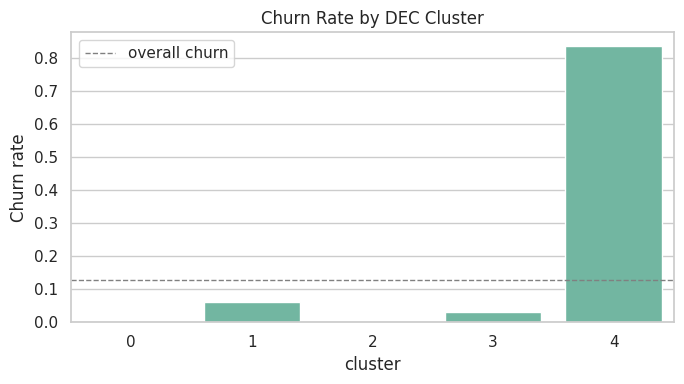

Saved DEC cluster inputs to: /kaggle/working/dec_outputs
Train DEC features: (595000, 18)
Test DEC features: (255000, 17)
Fused train shape: (476000, 211)
Fused valid shape: (119000, 211)


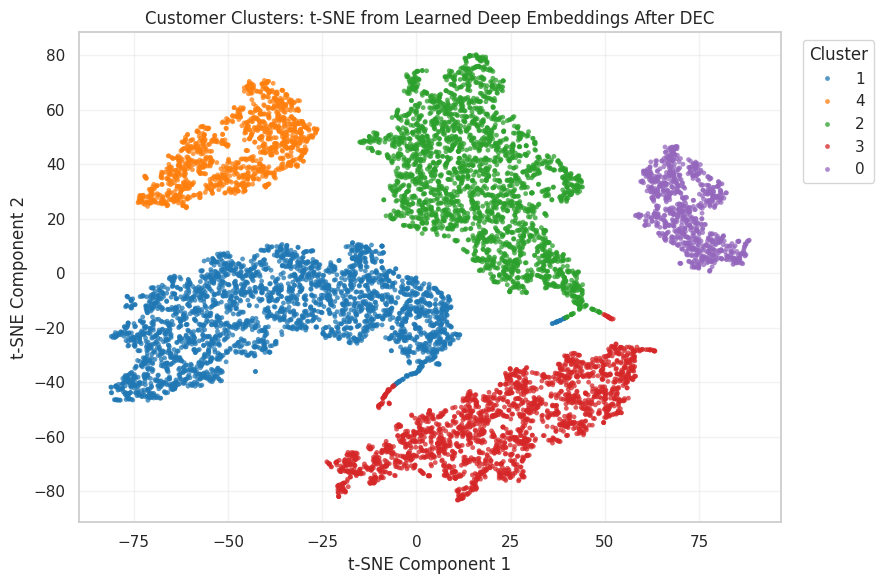

In [19]:
# Assign DEC clusters and create DEC-enhanced feature matrices and exportable cluster inputs

q_train = dec_model.predict(X_train, batch_size=4096, verbose=0)
q_valid = dec_model.predict(X_valid, batch_size=4096, verbose=0)
q_test = dec_model.predict(X_test_all, batch_size=4096, verbose=0)

cluster_train = q_train.argmax(axis=1)
cluster_valid = q_valid.argmax(axis=1)
cluster_test = q_test.argmax(axis=1)

Z_train_dec = encoder.predict(X_train, batch_size=4096, verbose=0)
Z_valid_dec = encoder.predict(X_valid, batch_size=4096, verbose=0)
Z_test_dec = encoder.predict(X_test_all, batch_size=4096, verbose=0)

cluster_train_oh = np.eye(N_CLUSTERS, dtype='float32')[cluster_train]
cluster_valid_oh = np.eye(N_CLUSTERS, dtype='float32')[cluster_valid]

# Fused representation for the GRU/LSTM cells below.
X_train_fused = np.concatenate([X_train, Z_train_dec, q_train, cluster_train_oh], axis=1).astype('float32')
X_valid_fused = np.concatenate([X_valid, Z_valid_dec, q_valid, cluster_valid_oh], axis=1).astype('float32')

cluster_report = pd.DataFrame({'cluster': cluster_train, 'CHURN': y_train}).groupby('cluster').agg(
    customers=('CHURN', 'size'),
    churn_rate=('CHURN', 'mean'),
    churners=('CHURN', 'sum')
).reset_index().sort_values('cluster')

display(cluster_report)
cluster_report.to_csv(DEC_OUTPUT_DIR / 'dec_cluster_report_train_split.csv', index=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=cluster_report, x='cluster', y='churn_rate')
plt.axhline(y_train.mean(), color='gray', linestyle='--', linewidth=1, label='overall churn')
plt.title('Churn Rate by DEC Cluster')
plt.ylabel('Churn rate')
plt.legend()
plt.tight_layout()
plt.savefig(DEC_OUTPUT_DIR / 'dec_cluster_churn_rate.png', dpi=160, bbox_inches='tight')
plt.show()

# Export cluster inputs for any downstream model.
def build_dec_output(account_ids, q, z, clusters, churn=None):
    out = pd.DataFrame({'ACCOUNT_ID': pd.Series(account_ids).astype(str).to_numpy()})
    out['dec_cluster'] = clusters.astype('int16')
    for j in range(q.shape[1]):
        out[f'dec_prob_{j}'] = q[:, j].astype('float32')
    for j in range(z.shape[1]):
        out[f'dec_latent_{j}'] = z[:, j].astype('float32')
    if churn is not None:
        out['CHURN'] = churn.astype(int)
    return out

# Full train/test DEC features are created from all available train rows and test rows.
q_all = dec_model.predict(X_all, batch_size=4096, verbose=0)
Z_all_dec = encoder.predict(X_all, batch_size=4096, verbose=0)
cluster_all = q_all.argmax(axis=1)

train_dec_features = build_dec_output(train_model_df['ACCOUNT_ID'], q_all, Z_all_dec, cluster_all, y.to_numpy())
test_dec_features = build_dec_output(test_model_df['ACCOUNT_ID'], q_test, Z_test_dec, cluster_test)
all_dec_features = pd.concat([
    train_dec_features.assign(split='train'),
    test_dec_features.assign(split='test'),
], ignore_index=True)

train_dec_features.to_parquet(DEC_OUTPUT_DIR / 'dec_cluster_inputs_train.parquet', index=False)
test_dec_features.to_parquet(DEC_OUTPUT_DIR / 'dec_cluster_inputs_test.parquet', index=False)
all_dec_features.to_parquet(DEC_OUTPUT_DIR / 'dec_cluster_inputs_all.parquet', index=False)

print('Saved DEC cluster inputs to:', DEC_OUTPUT_DIR)
print('Train DEC features:', train_dec_features.shape)
print('Test DEC features:', test_dec_features.shape)
print('Fused train shape:', X_train_fused.shape)
print('Fused valid shape:', X_valid_fused.shape)

# t-SNE visualization on a manageable sample of latent embeddings.
TSNE_SAMPLE_SIZE = min(10000, Z_all_dec.shape[0])
rng = np.random.default_rng(SEED)
tsne_idx = rng.choice(Z_all_dec.shape[0], size=TSNE_SAMPLE_SIZE, replace=False)

Z_tsne_input = Z_all_dec[tsne_idx]
cluster_tsne = cluster_all[tsne_idx]
churn_tsne = y.to_numpy()[tsne_idx]

tsne_kwargs = dict(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=SEED,
)
try:
    tsne = TSNE(**tsne_kwargs, max_iter=1000)
except TypeError:
    tsne = TSNE(**tsne_kwargs, n_iter=1000)
Z_tsne = tsne.fit_transform(Z_tsne_input)

tsne_df = pd.DataFrame({
    'tsne_1': Z_tsne[:, 0],
    'tsne_2': Z_tsne[:, 1],
    'cluster': cluster_tsne.astype(str),
    'CHURN': churn_tsne,
})
tsne_df.to_csv(DEC_OUTPUT_DIR / 'dec_tsne_sample.csv', index=False)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=tsne_df,
    x='tsne_1',
    y='tsne_2',
    hue='cluster',
    palette='tab10',
    s=12,
    alpha=0.75,
    linewidth=0,
)
plt.title('Customer Clusters: t-SNE from Learned Deep Embeddings After DEC')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(DEC_OUTPUT_DIR / 'dec_tsne_clusters.png', dpi=180, bbox_inches='tight')
plt.show()


### 6.8 · Export the DEC features

Writes the 18 columns consumed by `march-split-with-added-features.ipynb`: cluster identity, five soft assignments, ten latent dimensions, confidence and entropy. No label-derived field is exported.

In [20]:
# 20.6 Export Clean DEC Features for Teammate Models
# No label-derived cluster churn rate or cluster size.

EPS = 1e-12

def add_dec_uncertainty_features(df, prob_cols):
    probs = df[prob_cols].to_numpy()
    df["dec_confidence"] = probs.max(axis=1).astype("float32")
    df["dec_entropy"] = (-(probs * np.log(probs + EPS)).sum(axis=1)).astype("float32")
    return df

prob_cols = [c for c in train_dec_features.columns if c.startswith("dec_prob_")]

train_dec_export = train_dec_features.drop(columns=["CHURN"], errors="ignore").copy()
test_dec_export = test_dec_features.copy()

train_dec_export = add_dec_uncertainty_features(train_dec_export, prob_cols)
test_dec_export = add_dec_uncertainty_features(test_dec_export, prob_cols)

train_dec_export.to_parquet(
    DEC_OUTPUT_DIR / "dec_features_for_models_train.parquet",
    index=False
)

test_dec_export.to_parquet(
    DEC_OUTPUT_DIR / "dec_features_for_models_test.parquet",
    index=False
)

all_dec_export = pd.concat(
    [
        train_dec_export.assign(split="train"),
        test_dec_export.assign(split="test"),
    ],
    ignore_index=True
)

all_dec_export.to_parquet(
    DEC_OUTPUT_DIR / "dec_features_for_models_all.parquet",
    index=False
)

print("Saved clean DEC model features:")
print(DEC_OUTPUT_DIR / "dec_features_for_models_train.parquet")
print(DEC_OUTPUT_DIR / "dec_features_for_models_test.parquet")
print(DEC_OUTPUT_DIR / "dec_features_for_models_all.parquet")

print("Train DEC export:", train_dec_export.shape)
print("Test DEC export:", test_dec_export.shape)
print("All DEC export:", all_dec_export.shape)

display(train_dec_export.head())

Saved clean DEC model features:
/kaggle/working/dec_outputs/dec_features_for_models_train.parquet
/kaggle/working/dec_outputs/dec_features_for_models_test.parquet
/kaggle/working/dec_outputs/dec_features_for_models_all.parquet
Train DEC export: (595000, 19)
Test DEC export: (255000, 19)
All DEC export: (850000, 20)


,ACCOUNT_ID,dec_cluster,dec_prob_0,dec_prob_1,dec_prob_2,dec_prob_3,dec_prob_4,dec_latent_0,dec_latent_1,dec_latent_2,dec_latent_3,dec_latent_4,dec_latent_5,dec_latent_6,dec_latent_7,dec_latent_8,dec_latent_9,dec_confidence,dec_entropy
0,CUST00109362,3,0.000475,0.001662,0.001483,0.995993,0.000386,4.626128,-3.769823,-17.585064,-15.186442,-6.675539,-7.335147,4.889986,-4.817992,2.404690,-4.636788,0.995993,0.030970
1,CUST00480386,2,0.000866,0.001939,0.995295,0.001534,0.000366,-3.566939,6.012270,-11.476165,-4.992862,3.505906,1.035883,4.343795,4.293971,7.358004,7.878078,0.995295,0.035746
2,CUST00637759,3,0.000446,0.001613,0.001420,0.996154,0.000367,4.570611,-3.786897,-17.375607,-15.104668,-6.531924,-7.364038,4.825577,-4.621638,2.259362,-4.500299,0.996154,0.029868
3,CUST00303030,1,0.000331,0.995750,0.001774,0.001578,0.000567,3.410325,-3.981588,-4.747727,-8.388062,-0.290631,-8.776883,-1.293139,10.031162,-6.008066,3.377471,0.995750,0.032550
4,CUST00395836,1,0.000332,0.995743,0.001784,0.001576,0.000566,3.414418,-3.930216,-4.729586,-8.349710,-0.248739,-8.735231,-1.343733,10.047486,-5.976163,3.372479,0.995743,0.032597


Copies the export into the working directory.

In [21]:
import shutil

shutil.make_archive(
    "/kaggle/working/dec_outputs_package",
    "zip",
    "/kaggle/working/dec_outputs"
)

print("Download this:")
print("/kaggle/working/dec_outputs_package.zip")

Download this:
/kaggle/working/dec_outputs_package.zip


Optional: load precomputed DEC features instead of re-running the stage above.

In [13]:
# Optional: import precomputed DEC features before GRU/LSTM training.
# Use this if you already have dec_features_for_models_all.parquet.

USE_IMPORTED_DEC_FEATURES_FOR_DL = True

DEC_MODEL_FEATURE_PATH = Path(
    "/kaggle/input/datasets/jwuptr/dec-all/dec_features_for_models_all.parquet"
)

candidate_dec_paths = []
if DEC_MODEL_FEATURE_PATH is not None:
    candidate_dec_paths.append(Path(DEC_MODEL_FEATURE_PATH))

# If you upload the DEC output file as a Kaggle Dataset, this auto-detects it.
kaggle_input = Path("/kaggle/input")
if kaggle_input.exists():
    candidate_dec_paths += sorted(kaggle_input.glob("**/dec_features_for_models_all.parquet"))
    candidate_dec_paths += sorted(kaggle_input.glob("**/dec_cluster_inputs_all.parquet"))

candidate_dec_paths += [
    WORK_DIR / "dec_outputs" / "dec_features_for_models_all.parquet",
    WORK_DIR / "dec_outputs" / "dec_cluster_inputs_all.parquet",
    Path("/kaggle/working/dec_outputs/dec_features_for_models_all.parquet"),
    Path("/kaggle/working/dec_outputs/dec_cluster_inputs_all.parquet"),
]

# Remove duplicate paths while preserving priority order.
seen_paths = set()
candidate_dec_paths = [
    p for p in candidate_dec_paths
    if not (str(p) in seen_paths or seen_paths.add(str(p)))
]

print("Candidate DEC feature paths:")
for p in candidate_dec_paths[:10]:
    print("-", p)

dec_for_dl = None
for path in candidate_dec_paths:
    if path.exists():
        dec_for_dl = pd.read_parquet(path)
        print("Loaded precomputed DEC features from:", path)
        break

if dec_for_dl is None:
    raise FileNotFoundError(
        "Could not find DEC feature parquet. Set DEC_MODEL_FEATURE_PATH to your Kaggle input path."
    )

if "ACCOUNT_ID" not in dec_for_dl.columns:
    raise ValueError("DEC feature file must contain ACCOUNT_ID.")

dec_for_dl["ACCOUNT_ID"] = dec_for_dl["ACCOUNT_ID"].astype(str)
dec_for_dl = dec_for_dl.drop_duplicates(subset=["ACCOUNT_ID"]).copy()

prob_cols = sorted([c for c in dec_for_dl.columns if c.startswith("dec_prob_")])
latent_cols = sorted([c for c in dec_for_dl.columns if c.startswith("dec_latent_")])

if not prob_cols:
    raise ValueError("DEC file must contain dec_prob_* columns.")

if not latent_cols:
    print("Warning: no dec_latent_* columns found. GRU/LSTM will use probabilities/cluster features only.")

# Add confidence/entropy if the older DEC export did not include them.
EPS = 1e-12
probs_all = dec_for_dl[prob_cols].to_numpy(dtype="float32")

if "dec_confidence" not in dec_for_dl.columns:
    dec_for_dl["dec_confidence"] = probs_all.max(axis=1).astype("float32")

if "dec_entropy" not in dec_for_dl.columns:
    dec_for_dl["dec_entropy"] = (
        -(probs_all * np.log(probs_all + EPS)).sum(axis=1)
    ).astype("float32")

# Recreate the same train/validation split, but keep ACCOUNT_ID arrays for DEC joins.
account_ids_all = train_model_df["ACCOUNT_ID"].astype(str).to_numpy()
account_ids_test = test_model_df["ACCOUNT_ID"].astype(str).to_numpy()

X_train, X_valid, y_train, y_valid, train_ids_dl, valid_ids_dl = train_test_split(
    X_all,
    y.to_numpy(),
    account_ids_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

# Build a stable DEC feature matrix:
# soft probabilities + latent dims + confidence/entropy + one-hot hard cluster.
dec_for_dl = dec_for_dl.set_index("ACCOUNT_ID")

cluster_values = (
    sorted(dec_for_dl["dec_cluster"].dropna().astype(int).unique().tolist())
    if "dec_cluster" in dec_for_dl.columns
    else []
)

uncertainty_cols = [
    c for c in ["dec_confidence", "dec_entropy"]
    if c in dec_for_dl.columns
]

base_dec_cols = prob_cols + latent_cols + uncertainty_cols

def make_imported_dec_matrix(account_ids):
    part = dec_for_dl.reindex(pd.Series(account_ids).astype(str))

    missing_count = int(part[prob_cols[0]].isna().sum())
    if missing_count:
        print("Warning: missing DEC rows for", missing_count, "accounts; filling DEC values with 0.")

    matrix_parts = []

    if base_dec_cols:
        matrix_parts.append(
            part[base_dec_cols]
            .fillna(0)
            .astype("float32")
            .to_numpy()
        )

    if "dec_cluster" in part.columns and cluster_values:
        cluster_series = part["dec_cluster"].fillna(-1).astype(int)
        cluster_oh = pd.DataFrame(index=part.index)

        for k in cluster_values:
            cluster_oh[f"dec_cluster_ohe_{k}"] = (
                cluster_series == k
            ).astype("float32")

        matrix_parts.append(cluster_oh.to_numpy(dtype="float32"))

    if not matrix_parts:
        raise ValueError("No usable DEC columns found for GRU/LSTM input.")

    return np.concatenate(matrix_parts, axis=1).astype("float32")

dec_train_matrix = make_imported_dec_matrix(train_ids_dl)
dec_valid_matrix = make_imported_dec_matrix(valid_ids_dl)
dec_test_matrix = make_imported_dec_matrix(account_ids_test)

X_train_fused = np.concatenate([X_train, dec_train_matrix], axis=1).astype("float32")
X_valid_fused = np.concatenate([X_valid, dec_valid_matrix], axis=1).astype("float32")
X_test_fused = np.concatenate([X_test_all, dec_test_matrix], axis=1).astype("float32")

X_train_seq = X_train_fused.reshape((X_train_fused.shape[0], X_train_fused.shape[1], 1))
X_valid_seq = X_valid_fused.reshape((X_valid_fused.shape[0], X_valid_fused.shape[1], 1))
X_test_seq = X_test_fused.reshape((X_test_fused.shape[0], X_test_fused.shape[1], 1))

print("Imported DEC matrix shapes:")
print("dec_train_matrix:", dec_train_matrix.shape)
print("dec_valid_matrix:", dec_valid_matrix.shape)
print("dec_test_matrix:", dec_test_matrix.shape)
print("GRU/LSTM train sequence shape:", X_train_seq.shape)
print("GRU/LSTM valid sequence shape:", X_valid_seq.shape)
print("GRU/LSTM test sequence shape:", X_test_seq.shape)

Candidate DEC feature paths:
- /kaggle/input/datasets/jwuptr/dec-all/dec_features_for_models_all.parquet
- /kaggle/working/dec_outputs/dec_features_for_models_all.parquet
- /kaggle/working/dec_outputs/dec_cluster_inputs_all.parquet
Loaded precomputed DEC features from: /kaggle/input/datasets/jwuptr/dec-all/dec_features_for_models_all.parquet
Imported DEC matrix shapes:
dec_train_matrix: (476000, 22)
dec_valid_matrix: (119000, 22)
dec_test_matrix: (255000, 22)
GRU/LSTM train sequence shape: (476000, 213, 1)
GRU/LSTM valid sequence shape: (119000, 213, 1)
GRU/LSTM test sequence shape: (255000, 213, 1)


## Appendix · GRU and LSTM models

The cells below train recurrent models on the DEC-enhanced matrix and generate competition submissions. They are not part of XMV-Net and are retained as a record of the original work.

Reshapes each feature vector into a sequence for the recurrent models.

In [14]:
# Reshape tabular feature vectors into feature sequences for recurrent models.
# Shape required by GRU/LSTM: (samples, timesteps, features_per_timestep).

X_train_seq = X_train_fused.reshape((X_train_fused.shape[0], X_train_fused.shape[1], 1))
X_valid_seq = X_valid_fused.reshape((X_valid_fused.shape[0], X_valid_fused.shape[1], 1))

print('GRU/LSTM train sequence shape:', X_train_seq.shape)
print('GRU/LSTM valid sequence shape:', X_valid_seq.shape)

GRU/LSTM train sequence shape: (476000, 213, 1)
GRU/LSTM valid sequence shape: (119000, 213, 1)


### GRU training and evaluation

Model: "DEC_GRU_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 213, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 213, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - auc: 0.9347 - loss: 0.1618 - precision: 0.8381 - recall: 0.7736 - val_auc: 0.9438 - val_loss: 0.1465 - val_precision: 0.8882 - val_recall: 0.7064 - learning_rate: 0.0010
Epoch 2/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - auc: 0.9411 - loss: 0.1466 - precision: 0.8404 - recall: 0.7858 - val_auc: 0.9462 - val_loss: 0.1450 - val_precision: 0.8316 - val_recall: 0.7965 - learning_rate: 0.0010
Epoch 3/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9423 - loss: 0.1457 - precision: 0.8384 - recall: 0.7895 - val_auc: 0.9476 - val_loss: 0.1439 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 0.0010
Epoch 4/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9431 - loss: 0.1451 - precision: 0.8393 - recall: 0.7879 - val_auc: 0.9494 - val_loss: 0.1432 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 0.0010
Epoch 5/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9487 - loss: 0.1428 - p

,model,accuracy,precision,recall,f1,roc_auc,avg_precision
0,DEC + GRU,0.954798,0.867894,0.758998,0.809802,0.983343,0.91134


              precision    recall  f1-score   support

           0     0.9656    0.9832    0.9744    103913
           1     0.8679    0.7590    0.8098     15087

    accuracy                         0.9548    119000
   macro avg     0.9168    0.8711    0.8921    119000
weighted avg     0.9532    0.9548    0.9535    119000



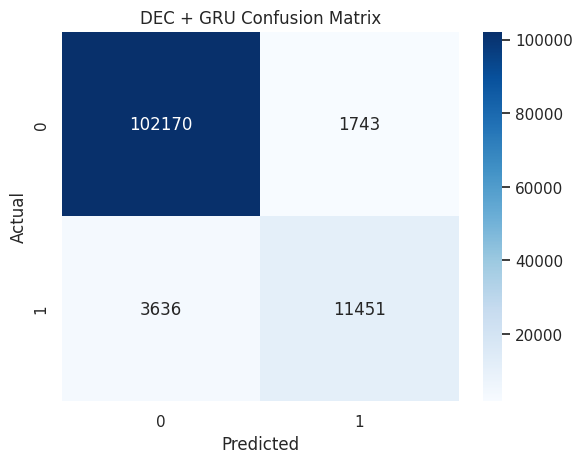

In [20]:
def evaluate_binary_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
    }
    display(pd.DataFrame([metrics]))
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    return metrics


def build_gru_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, activation='tanh', return_sequences=True),
        layers.Dropout(0.2),
        layers.GRU(32, activation='tanh'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ], name='DEC_GRU_Churn')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

gru_model = build_gru_model(X_train_seq.shape[1:])
gru_model.summary()

DL_EPOCHS = 50
DL_BATCH_SIZE = 256  # Paper uses 32; larger batch is practical for this dataset size.

dl_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

history_gru = gru_model.fit(
    X_train_seq, y_train,
    validation_data=(X_valid_seq, y_valid),
    epochs=DL_EPOCHS,
    batch_size=DL_BATCH_SIZE,
    callbacks=dl_callbacks,
    verbose=1,
)

gru_prob = gru_model.predict(X_valid_seq, batch_size=4096, verbose=0).ravel()
gru_metrics = evaluate_binary_model('DEC + GRU', y_valid, gru_prob)

GRU training curves.

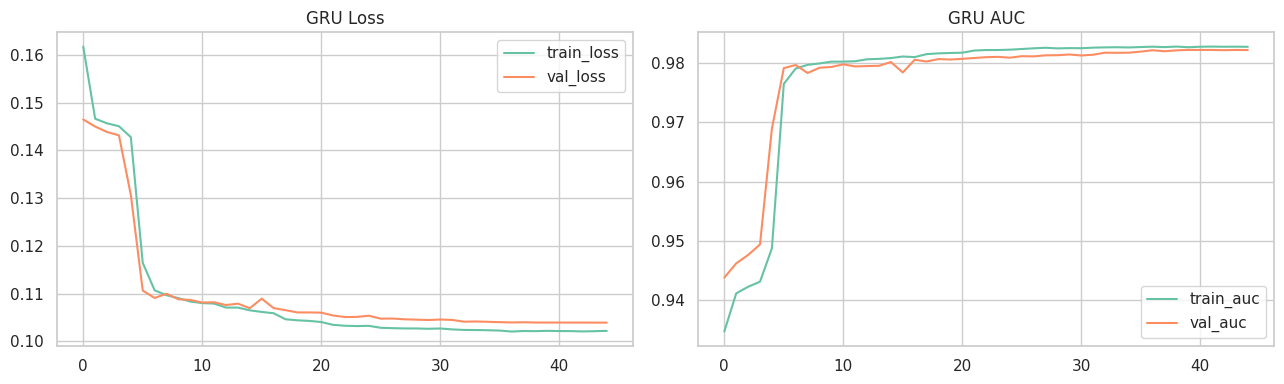

In [21]:
# GRU training curves

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_gru.history['loss'], label='train_loss')
axes[0].plot(history_gru.history['val_loss'], label='val_loss')
axes[0].set_title('GRU Loss')
axes[0].legend()

axes[1].plot(history_gru.history['auc'], label='train_auc')
axes[1].plot(history_gru.history['val_auc'], label='val_auc')
axes[1].set_title('GRU AUC')
axes[1].legend()
plt.tight_layout()
plt.show()

### LSTM training and evaluation

Model: "DEC_LSTM_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 213, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 213, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - auc: 0.9614 - loss: 0.1416 - precision: 0.8356 - recall: 0.7766 - val_auc: 0.9764 - val_loss: 0.1176 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 0.0010
Epoch 2/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9764 - loss: 0.1163 - precision: 0.8362 - recall: 0.7937 - val_auc: 0.9769 - val_loss: 0.1133 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 0.0010
Epoch 3/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - auc: 0.9788 - loss: 0.1109 - precision: 0.8361 - recall: 0.7942 - val_auc: 0.9794 - val_loss: 0.1095 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 5.0000e-04
Epoch 4/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - auc: 0.9799 - loss: 0.1090 - precision: 0.8367 - recall: 0.7934 - val_auc: 0.9792 - val_loss: 0.1091 - val_precision: 0.8315 - val_recall: 0.7968 - learning_rate: 5.0000e-04
Epoch 5/50
1860/1860 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - auc: 0.9806 - loss: 0.

,model,accuracy,precision,recall,f1,roc_auc,avg_precision
0,DEC + LSTM,0.953773,0.831512,0.796845,0.813809,0.97803,0.890176


              precision    recall  f1-score   support

           0     0.9707    0.9766    0.9736    103913
           1     0.8315    0.7968    0.8138     15087

    accuracy                         0.9538    119000
   macro avg     0.9011    0.8867    0.8937    119000
weighted avg     0.9530    0.9538    0.9534    119000



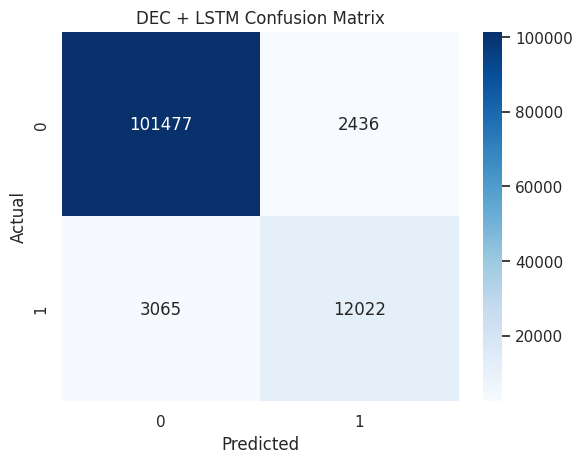

In [22]:
def build_lstm_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, activation='tanh', return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, activation='tanh'),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ], name='DEC_LSTM_Churn')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

lstm_model = build_lstm_model(X_train_seq.shape[1:])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_valid_seq, y_valid),
    epochs=DL_EPOCHS,
    batch_size=DL_BATCH_SIZE,
    callbacks=dl_callbacks,
    verbose=1,
)

lstm_prob = lstm_model.predict(X_valid_seq, batch_size=4096, verbose=0).ravel()
lstm_metrics = evaluate_binary_model('DEC + LSTM', y_valid, lstm_prob)

LSTM curves, and comparison against the GRU.

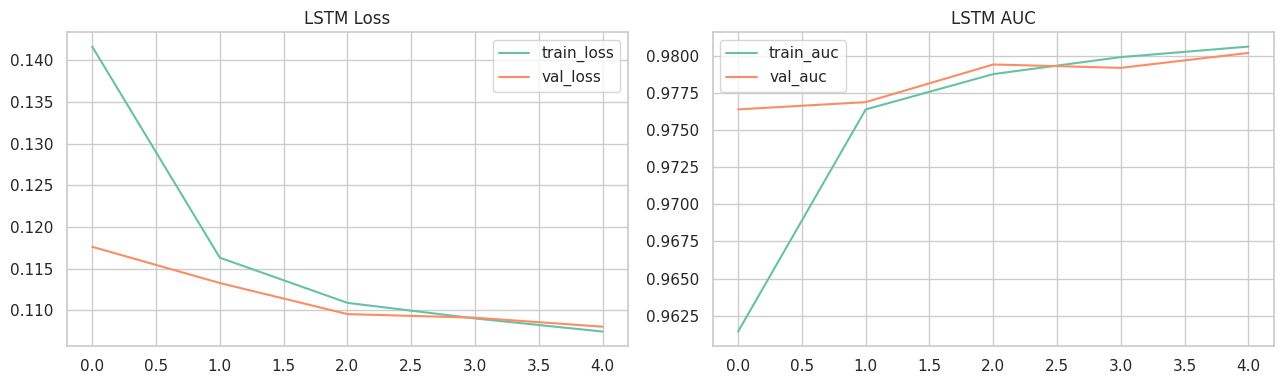

,model,accuracy,precision,recall,f1,roc_auc,avg_precision
0,DEC + GRU,0.954798,0.867894,0.758998,0.809802,0.983343,0.911340
1,DEC + LSTM,0.953773,0.831512,0.796845,0.813809,0.978030,0.890176


In [23]:
# LSTM training curves and model comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_lstm.history['loss'], label='train_loss')
axes[0].plot(history_lstm.history['val_loss'], label='val_loss')
axes[0].set_title('LSTM Loss')
axes[0].legend()

axes[1].plot(history_lstm.history['auc'], label='train_auc')
axes[1].plot(history_lstm.history['val_auc'], label='val_auc')
axes[1].set_title('LSTM AUC')
axes[1].legend()
plt.tight_layout()
plt.show()

comparison = pd.DataFrame([gru_metrics, lstm_metrics]).sort_values('roc_auc', ascending=False)
display(comparison)

### Test predictions

Scores the test set with the better of the two recurrent models.

In [25]:
# Submission generation using imported DEC features + trained GRU model

best_model_name = "DEC + GRU"
best_model = gru_model

if "X_test_seq" not in globals():
    raise ValueError(
        "X_test_seq not found. Run the imported DEC feature cell before this submission cell."
    )

test_prob = best_model.predict(
    X_test_seq,
    batch_size=4096,
    verbose=1
).ravel()

submission_dec_dl = pd.DataFrame({
    "ACCOUNT_ID": test_ids["ACCOUNT_ID"].astype(str),
    "CHURN_PROB": np.clip(test_prob, 0, 1),
})

submission_path = WORK_DIR / "submission_dec_gru_imported_dec.csv"
submission_dec_dl.to_csv(submission_path, index=False)

display(submission_dec_dl.head())
print("Saved:", submission_path)
print("Best model used:", best_model_name)
print(submission_dec_dl["CHURN_PROB"].describe())

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step


,ACCOUNT_ID,CHURN_PROB
0,CUST00074385,0.943306
1,CUST00290073,0.000076
2,CUST00247934,0.001293
3,CUST00314276,0.186930
4,CUST00522755,0.345721


Saved: /kaggle/working/submission_dec_gru_imported_dec.csv
Best model used: DEC + GRU
count    255000.000000
mean          0.127282
std           0.281157
min           0.000034
25%           0.000092
50%           0.001004
75%           0.016330
max           0.998116
Name: CHURN_PROB, dtype: float64


Alternative submission path for the better model.

In [24]:
# Optional submission generation for the better deep model

best_model_name = comparison.iloc[0]['model']
best_model = gru_model if best_model_name == 'DEC + GRU' else lstm_model

Z_test_dec = encoder.predict(X_test_all, batch_size=4096, verbose=0)
q_test = dec_model.predict(X_test_all, batch_size=4096, verbose=0)
cluster_test = q_test.argmax(axis=1)
cluster_test_oh = np.eye(N_CLUSTERS, dtype='float32')[cluster_test]

X_test_fused = np.concatenate([X_test_all, Z_test_dec, q_test, cluster_test_oh], axis=1).astype('float32')
X_test_seq = X_test_fused.reshape((X_test_fused.shape[0], X_test_fused.shape[1], 1))

test_prob = best_model.predict(X_test_seq, batch_size=4096, verbose=1).ravel()

submission_dec_dl = pd.DataFrame({
    'ACCOUNT_ID': test_ids['ACCOUNT_ID'],
    'CHURN_PROB': np.clip(test_prob, 0, 1),
})

submission_path = WORK_DIR / 'submission_dec_gru_lstm.csv'
submission_dec_dl.to_csv(submission_path, index=False)

display(submission_dec_dl.head())
print('Saved:', submission_path)
print('Best model used:', best_model_name)
print(submission_dec_dl['CHURN_PROB'].describe())

NameError: name 'encoder' is not defined